
esm-piControl
Found 25 files
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/tas_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/tas_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/tas_Amon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_195101-195912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/tas_Amon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_225001-225012.nc

esm-up2p0-swl4p0
Found 29 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up

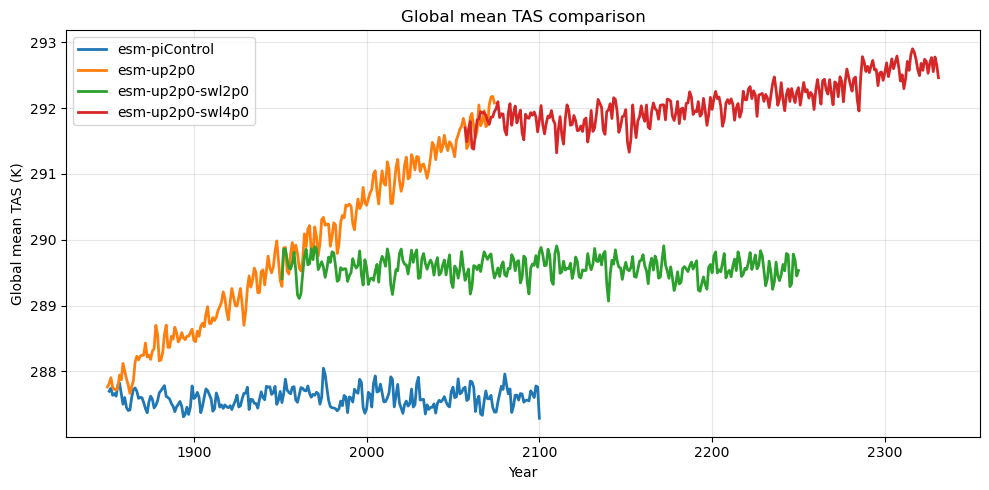

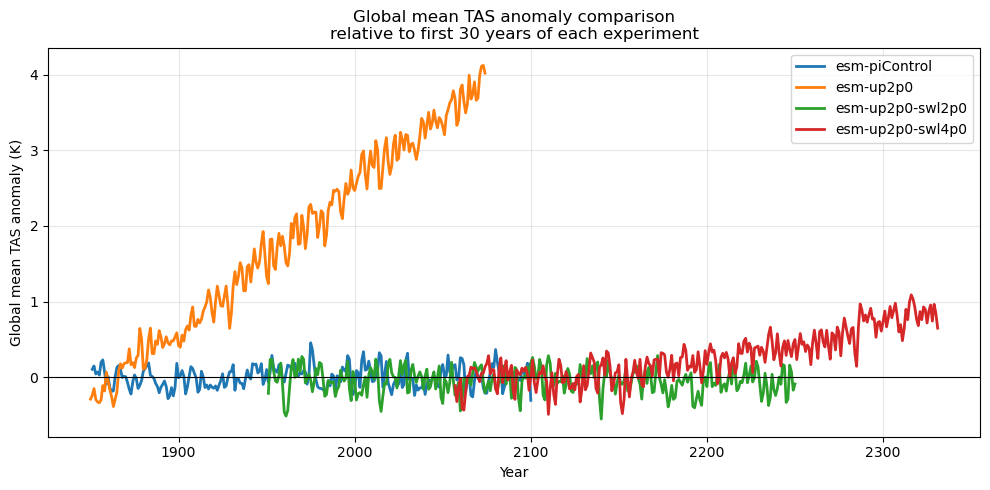

In [1]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Amon/tas/gn/latest",
        "pattern": "tas_Amon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010",
        "pattern": "tas_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009",
        "pattern": "tas_Amon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl4p0/v20251010",
        "pattern": "tas_Amon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gn_*.nc",
    },
}


# ============================================================
# Function
# ============================================================

def load_global_mean_tas(exp_path, pattern):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        parallel=False,
    )

    tas = ds["tas"]

    weights = np.cos(np.deg2rad(ds["lat"]))
    weights = weights / weights.mean()

    tas_gm = tas.weighted(weights).mean(dim=["lat", "lon"])

    tas_gm.name = "tas_global_mean"
    tas_gm.attrs["units"] = tas.attrs.get("units", "K")

    tas_ann = tas_gm.groupby("time.year").mean("time")
    tas_ann.name = "tas_global_mean_annual"

    ds.close()

    return tas_ann


# ============================================================
# Load all experiments
# ============================================================

tas_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    tas_ann_dict[exp] = load_global_mean_tas(
        exp_path=info["path"],
        pattern=info["pattern"],
    )


# ============================================================
# Plot absolute TAS
# ============================================================

plt.figure(figsize=(10, 5))

for exp, tas_ann in tas_ann_dict.items():
    plt.plot(
        tas_ann["year"],
        tas_ann,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global mean TAS (K)")
plt.title("Global mean TAS comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot anomalies relative to each experiment's first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, tas_ann in tas_ann_dict.items():
    years = tas_ann["year"].values
    ref_years = years[:30]

    tas_ref = tas_ann.sel(year=ref_years).mean("year")
    tas_anom = tas_ann - tas_ref

    plt.plot(
        tas_ann["year"],
        tas_anom,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Global mean TAS anomaly (K)")
plt.title("Global mean TAS anomaly comparison\nrelative to first 30 years of each experiment")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/tas_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/tas_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/tas_Amon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_195101-195912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/tas_Amon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_225001-225012.nc

esm-up2p0-swl4p0
Found 29 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up

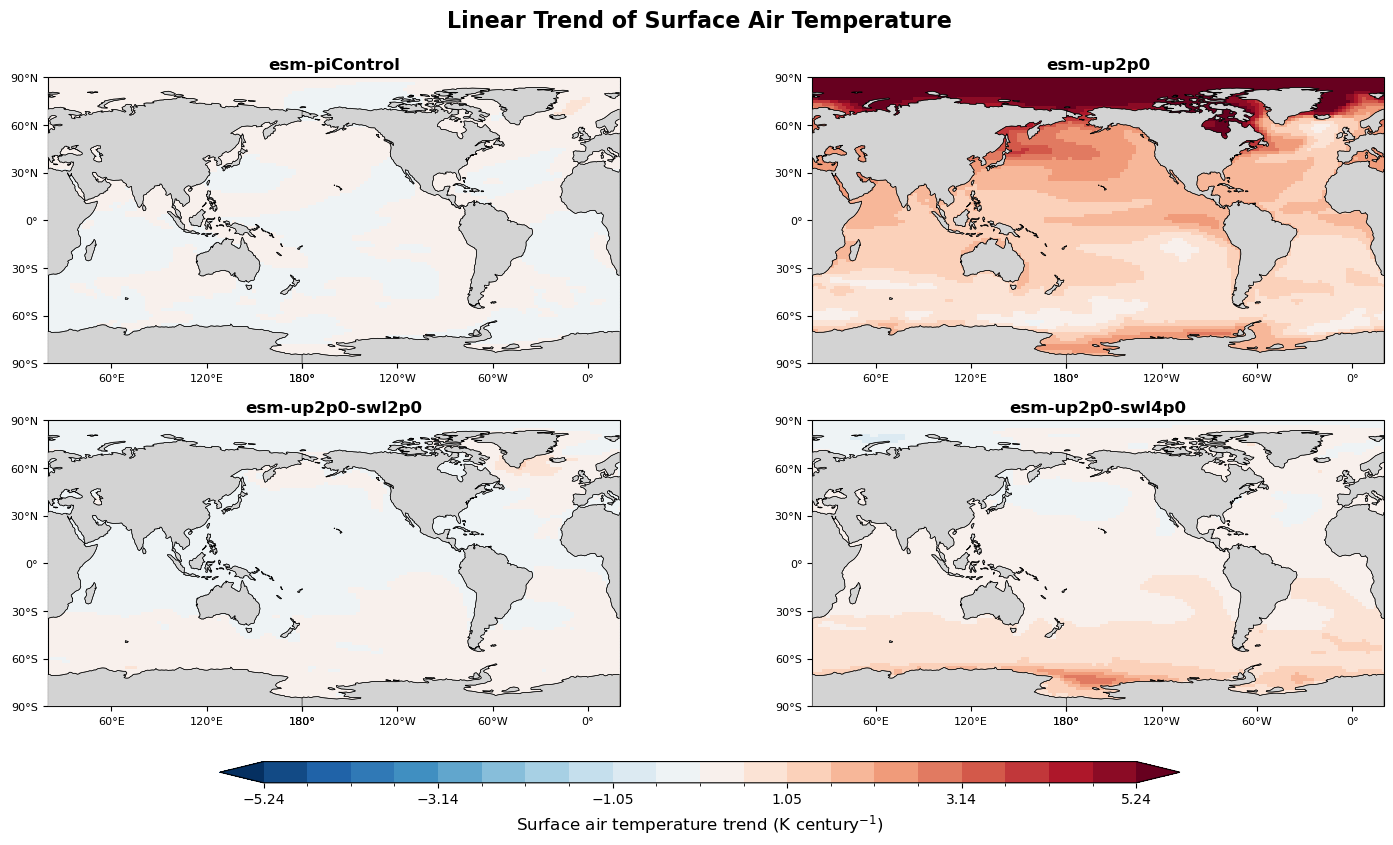

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Amon/tas/gn/latest",
        "pattern": "tas_Amon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010",
        "pattern": "tas_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009",
        "pattern": "tas_Amon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl4p0/v20251010",
        "pattern": "tas_Amon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gn_*.nc",
    },
}


# ============================================================
# Function
# ============================================================

def compute_tas_trend_map(exp_path, pattern):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    tas = ds["tas"]

    # Annual mean
    tas_ann = tas.groupby("time.year").mean("time")

    # Linear trend at each grid point
    # Unit: K per century
    year = tas_ann["year"]
    x = year - year.mean()

    trend = (
        (tas_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    trend.name = "tas_trend"
    trend.attrs["units"] = "K century-1"

    trend = trend.compute()

    ds.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_tas_trend_map(
        exp_path=info["path"],
        pattern=info["pattern"],
    )


# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# ------------------------------------------------------------
# common color range: based only on esm-up2p0
# cover about 90% of esm-up2p0 trend magnitudes
# ------------------------------------------------------------

ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 90)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# ------------------------------------------------------------
# draw maps
# ------------------------------------------------------------

for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["lon"],
        trend["lat"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# ------------------------------------------------------------
# layout first, then add colorbar outside
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "Surface air temperature trend (K century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of Surface Air Temperature",
    fontsize=16,
    fontweight="bold",
)

plt.show()


esm-piControl
Found 25 files
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/o2os/gn/latest/o2os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/o2os/gn/latest/o2os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2os_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2os_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2os_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_195101-195912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2os_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_225001-225012.nc

esm-up2p0-swl4p0
Found 29 files
/nird/datalake/NS2980K/projects/TipESM/cmo

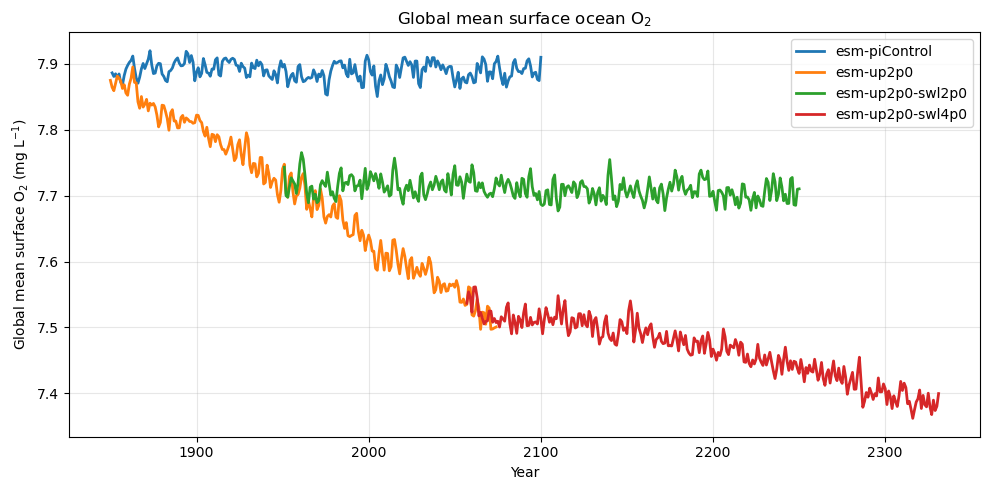

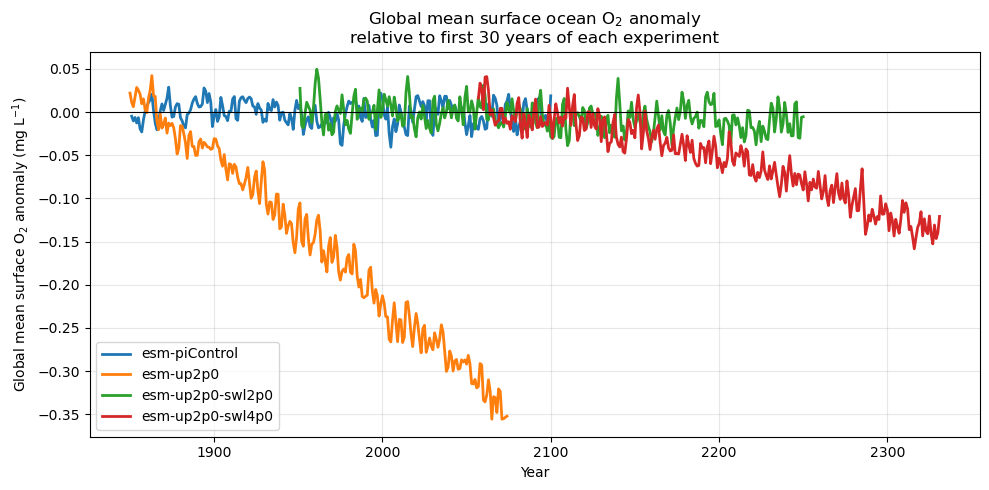


 esm-piControl
      o2os_global_mean_annual
year                         
1851                 7.886276
1852                 7.880795
1853                 7.884869
1854                 7.878471
1855                 7.884609
      o2os_global_mean_annual
year                         
2096                 7.886066
2097                 7.887206
2098                 7.876413
2099                 7.874506
2100                 7.909895
Mean: 7.889739036560059
Min : 7.8503642082214355
Max : 7.919887542724609

 esm-up2p0
      o2os_global_mean_annual
year                         
1850                 7.874935
1851                 7.864269
1852                 7.859202
1853                 7.870315
1854                 7.881483
      o2os_global_mean_annual
year                         
2070                 7.529395
2071                 7.497250
2072                 7.497722
2073                 7.499411
2074                 7.500680
Mean: 7.697524547576904
Min : 7.497161865234375
Max : 7.895

In [2]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/o2os/gn/latest",
        "pattern": "o2os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010",
        "pattern": "o2os_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009",
        "pattern": "o2os_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl4p0/v20251010",
        "pattern": "o2os_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gn_*.nc",
    },
}

AREACELLO_FILE = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "areacello_Ofx_NorESM2-LM_esm-up2p0_r1i1p1f1_gn.nc"
)

O2_MOLAR_MASS = 31.998  # mol m-3 -> mg L-1


# ============================================================
# Load areacello
# ============================================================

ds_area = xr.open_dataset(AREACELLO_FILE)
areacello = ds_area["areacello"]

# Remove possible non-spatial dimensions
for dim in list(areacello.dims):
    if dim not in ["j", "i"]:
        areacello = areacello.isel({dim: 0})

areacello = areacello.squeeze(drop=True)
areacello = areacello.where(np.isfinite(areacello))


# ============================================================
# Function
# ============================================================

def load_global_mean_o2os(exp_path, pattern, areacello):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        parallel=False,
    )

    o2os = ds["o2os"]

    # Convert from mol m-3 to mg L-1
    o2os_mg_L = o2os * O2_MOLAR_MASS
    o2os_mg_L.attrs["units"] = "mg L-1"

    # Mask area using valid ocean values
    area = areacello.where(np.isfinite(o2os_mg_L.isel(time=0)))

    # Area-weighted global ocean mean
    o2os_gm = (o2os_mg_L * area).sum(dim=["j", "i"]) / area.sum(dim=["j", "i"])

    o2os_gm.name = "o2os_global_mean"
    o2os_gm.attrs["units"] = "mg L-1"

    o2os_ann = o2os_gm.groupby("time.year").mean("time")
    o2os_ann.name = "o2os_global_mean_annual"

    ds.close()

    return o2os_ann


# ============================================================
# Load all experiments
# ============================================================

o2os_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2os_ann_dict[exp] = load_global_mean_o2os(
        exp_path=info["path"],
        pattern=info["pattern"],
        areacello=areacello,
    )


# ============================================================
# Plot absolute global mean o2os
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2os_ann in o2os_ann_dict.items():
    plt.plot(
        o2os_ann["year"],
        o2os_ann,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global mean surface O$_2$ (mg L$^{-1}$)")
plt.title("Global mean surface ocean O$_2$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot anomalies relative to each experiment's first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2os_ann in o2os_ann_dict.items():
    ref = o2os_ann.isel(year=slice(0, 30)).mean("year")
    o2os_anom = o2os_ann - ref

    plt.plot(
        o2os_ann["year"],
        o2os_anom,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)

plt.xlabel("Year")
plt.ylabel("Global mean surface O$_2$ anomaly (mg L$^{-1}$)")
plt.title("Global mean surface ocean O$_2$ anomaly\nrelative to first 30 years of each experiment")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Quick check
# ============================================================

for exp, o2os_ann in o2os_ann_dict.items():
    print("\n", exp)
    print(o2os_ann.to_dataframe().head())
    print(o2os_ann.to_dataframe().tail())
    print("Mean:", float(o2os_ann.mean()))
    print("Min :", float(o2os_ann.min()))
    print("Max :", float(o2os_ann.max()))

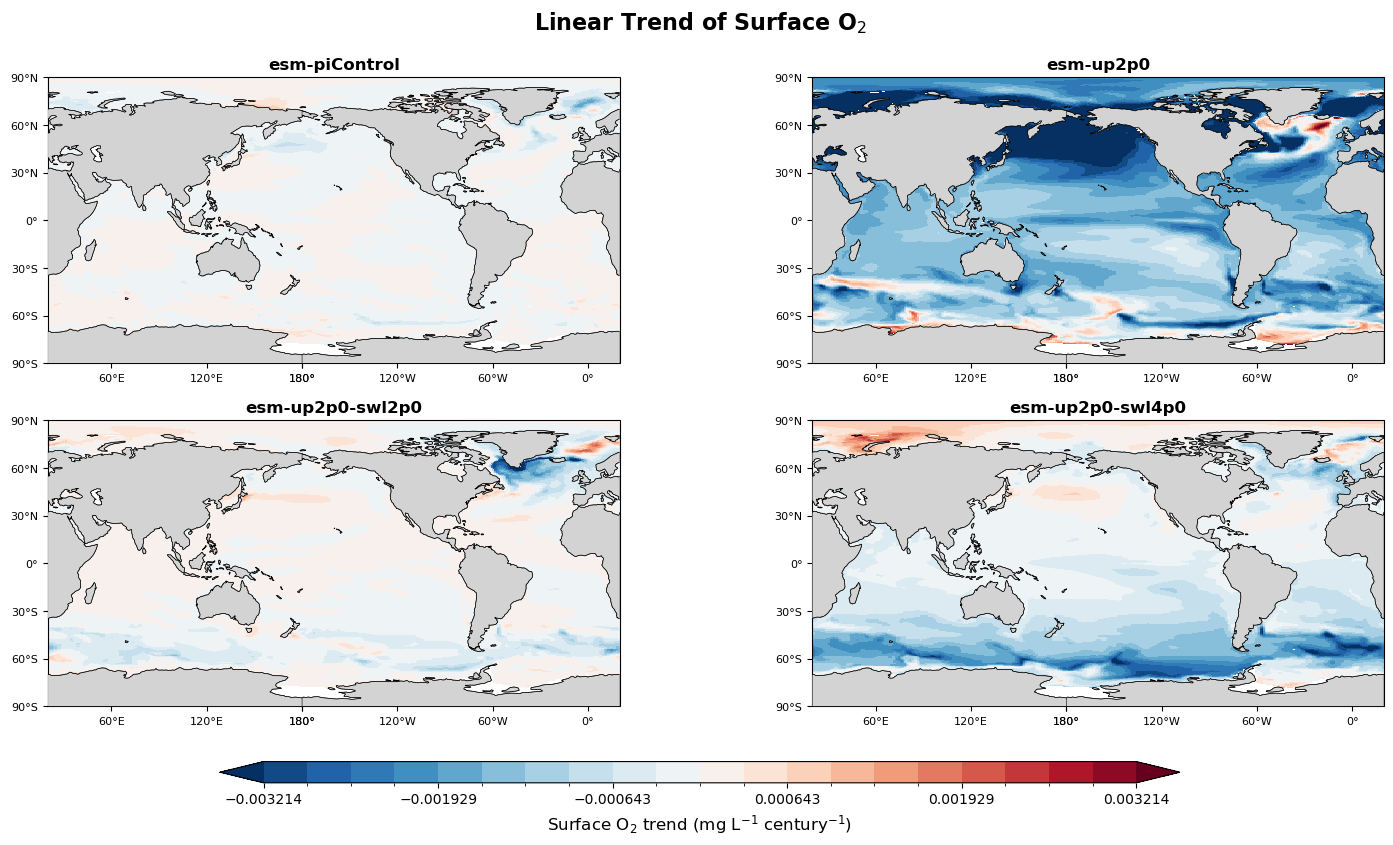

In [7]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors 
import cartopy.crs as ccrs 
import cartopy.feature as cfeature 
import cartopy.mpl.ticker as cticker 
import glob 
import warnings

# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# ------------------------------------------------------------
# common color range: cover about 90% of trend magnitudes
# ------------------------------------------------------------

all_values = []

for trend in trend_dict.values():
    tmp = trend.values
    all_values.append(tmp[np.isfinite(tmp)])

all_values = np.concatenate(all_values)

vmax = np.nanpercentile(np.abs(all_values), 90)
vmin = -vmax

# ------------------------------------------------------------
# common color range: based only on esm-up2p0
# cover about 90% of esm-up2p0 trend magnitudes
# ------------------------------------------------------------

ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 90)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

# Need enough colors for extend="both"
cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# ------------------------------------------------------------
# draw maps
# ------------------------------------------------------------

for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# ------------------------------------------------------------
# layout first, then add colorbar outside
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

# [left, bottom, width, height]
cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "Surface O$_2$ trend (mg L$^{-1}$ century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of Surface O$_2$",
    fontsize=16,
    fontweight="bold",
)

plt.show()


esm-piControl
Found 25 files
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Emon/t20d/gn/latest/t20d_Emon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Emon/t20d/gn/latest/t20d_Emon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/t20d_Emon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/t20d_Emon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/t20d_Emon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_195101-195912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009/t20d_Emon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_225001-225012.nc

esm-up2p0-swl4p0
Found 29 files
/nird/datalake/NS2980K/projects/TipESM/cmo

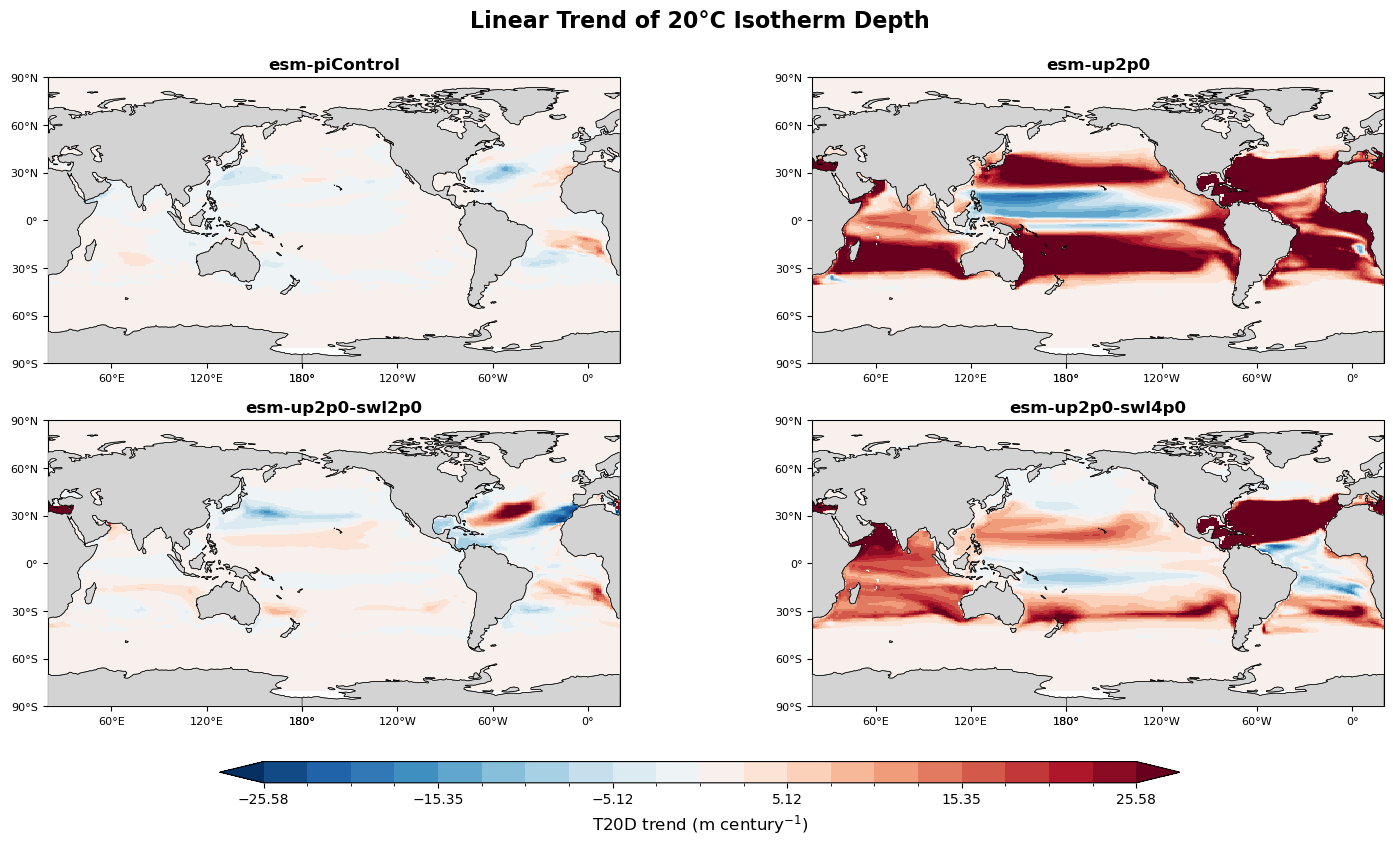

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Emon/t20d/gn/latest",
        "pattern": "t20d_Emon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010",
        "pattern": "t20d_Emon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009",
        "pattern": "t20d_Emon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl4p0/v20251010",
        "pattern": "t20d_Emon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gn_*.nc",
    },
}

VAR_NAME = "t20d"


# ============================================================
# Function
# ============================================================

def compute_t20d_trend_map(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    t20d = ds[var_name]

    fill_value = t20d.attrs.get("_FillValue", None)
    if fill_value is not None:
        t20d = t20d.where(t20d != fill_value)

    t20d_ann = t20d.groupby("time.year").mean("time")

    year = t20d_ann["year"]
    x = year - year.mean()

    # Trend: m per century
    trend = (
        (t20d_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    trend.name = "t20d_trend"
    trend.attrs["units"] = "m century-1"

    trend = trend.assign_coords(
        longitude=ds["longitude"],
        latitude=ds["latitude"],
    )

    trend = trend.compute()

    ds.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_t20d_trend_map(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
    )


# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# Color range based only on esm-up2p0, covering about 90%
ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 90)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# Draw maps
for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "T20D trend (m century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of 20°C Isotherm Depth",
    fontsize=16,
    fontweight="bold",
)

plt.show()